Mounted at /content/drive
결측치 삭제 후 남은 데이터 개수: 712개 (원래 891개)



<Figure size 1000x800 with 0 Axes>

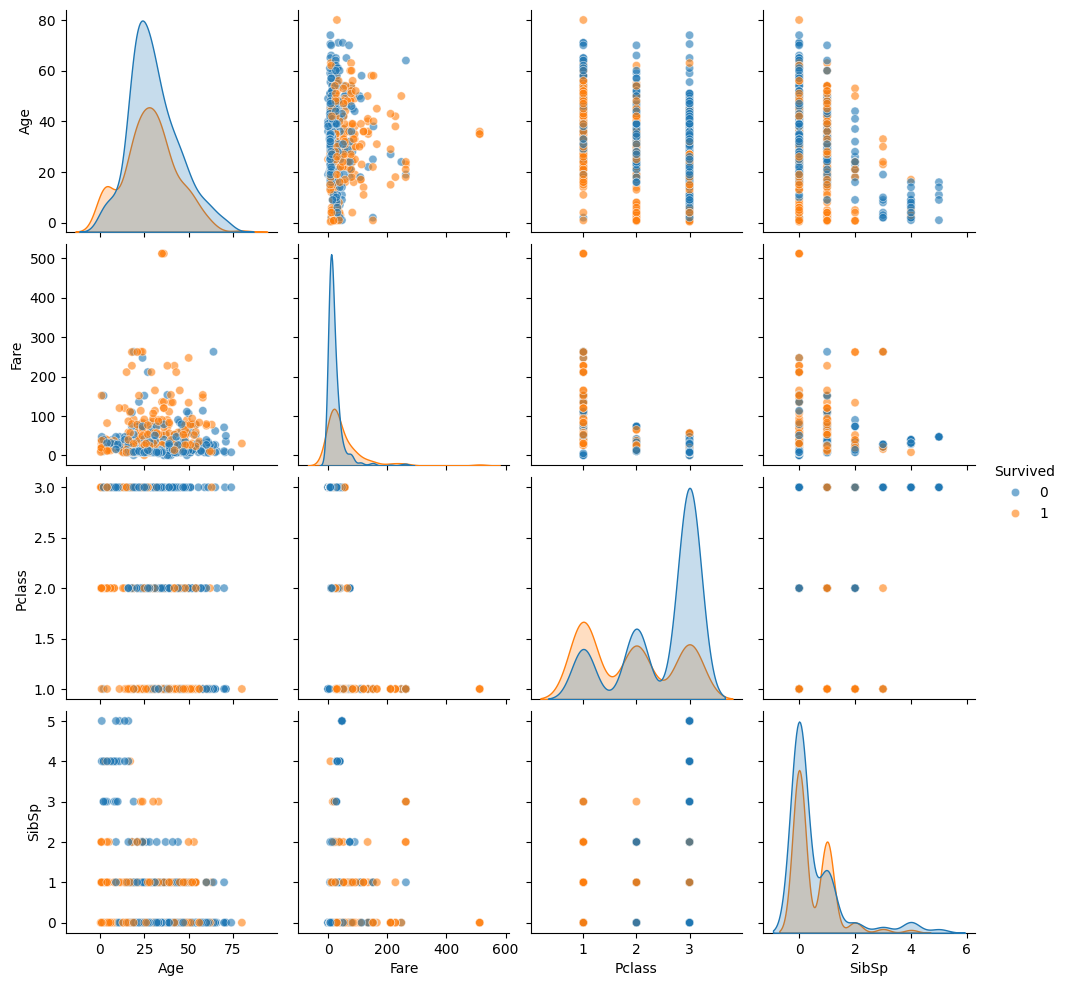

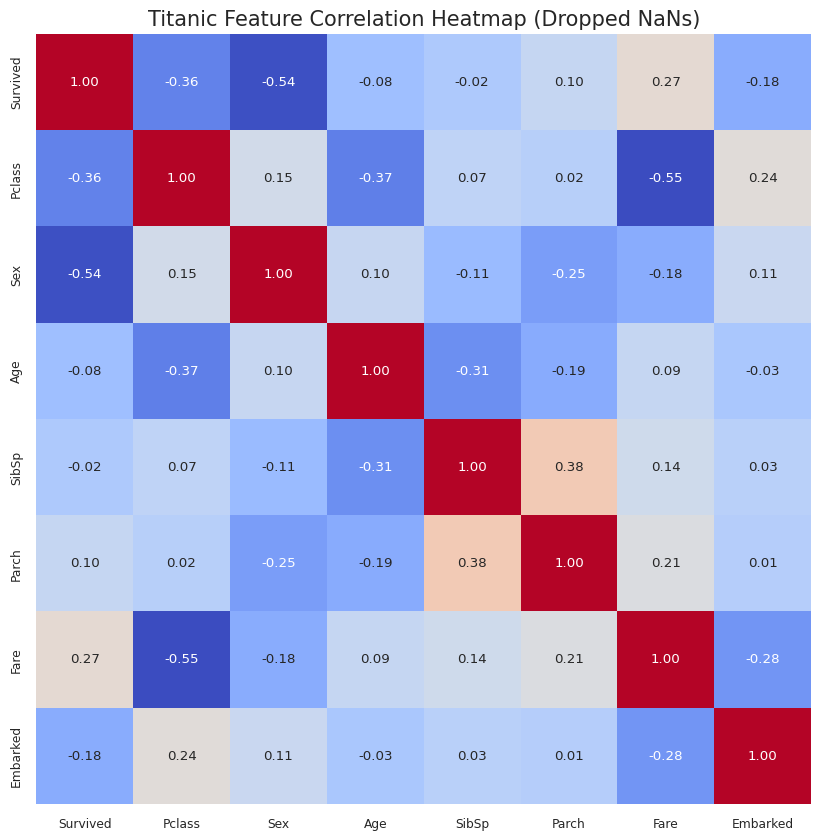

--- Logistic Regression ---
정확도: 0.7921348314606742

--- Decision Tree Classifier ---
정확도: 0.7528089887640449

--- Random Forest ---
정확도: 0.797752808988764

--- KNN (K-Nearest Neighbors) ---
정확도: 0.651685393258427


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/titanic.csv'
df = pd.read_csv(file_path)


df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)


df = df.dropna()
print(f"결측치 삭제 후 남은 데이터 개수: {len(df)}개 (원래 891개)\n")


plt.figure(figsize=(10, 8))
sns.pairplot(df,
             vars=['Age', 'Fare', 'Pclass', 'SibSp'],
             hue='Survived',
             plot_kws={'alpha': 0.6})
plt.show()

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])


df_corr = df.corr()
plt.figure(figsize=(10, 10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False, cmap='coolwarm', fmt='.2f')
plt.title('Titanic Feature Correlation Heatmap (Dropped NaNs)', fontsize=15)
plt.show()

sns.set(font_scale=1.0)


y = df['Survived']
X = df.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


model_lr = LogisticRegression(max_iter=500, random_state=0)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
print("--- Logistic Regression ---")
print("정확도:", accuracy_score(y_test, pred_lr))


clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)
pred_dt = clf_dt.predict(X_test)
print("\n--- Decision Tree Classifier ---")
print("정확도:", accuracy_score(y_test, pred_dt))


rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred_rf = rf_clf.predict(X_test)
print("\n--- Random Forest ---")
print("정확도:", accuracy_score(y_test, pred_rf))


knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
pred_knn = knn_clf.predict(X_test)
print("\n--- KNN (K-Nearest Neighbors) ---")
print("정확도:", accuracy_score(y_test, pred_knn))